# Steering-Strength Ablation: alpha (swap_bias) vs. AUC/F1/Accuracy

Every prior steering run used a fixed, saturating intervention magnitude
(`swap_bias = 10000.0` in `vis_head/steering.py`'s `make_static_attention_mask_hook`
— an additive pre-softmax bias large enough to fully override the original
attention logits, i.e. a **hard** intervention: the targeted heads' attention is
driven to ~1.0 on the target region regardless of what the unmodified attention
pattern looked like).

This notebook treats that magnitude as a continuous **alpha** parameter and sweeps
it from 0 (no intervention) up to the saturating default, to see how the causal
effect scales with intervention strength rather than only reporting the
all-or-nothing endpoint. `TOP_K_HEADS` is held fixed at 15 (the project default).

**Metric change**: rather than generating text and regex-parsing a letter (as in
the other MCQ notebooks), this notebook reads the model's next-token logits
directly at the answer position in a single forward pass, restricted to the four
option-letter tokens. This is faster (no multi-token generation) and gives a
genuine probability distribution over the four options, enabling:
- **accuracy** (argmax matches the correct letter)
- **macro F1** (same discrete predictions)
- **macro one-vs-rest AUC** (using the actual softmax probabilities — not
  available from parsed generation text alone)

across the three Qwen2-VL training stages (base/instruct/agentic).

In [1]:
%matplotlib inline
import gc
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "vis_head").exists():
    raise RuntimeError("Run this notebook from the repository root (vis-head/).")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm

from vis_head.common import DEFAULT_SEED
from vis_head.gaze import aggregate_region_attention, collect_last_query_attentions, rank_heads_by_score
from vis_head.imagenet_grid import DEFAULT_IMAGENET_ROOT, PROMPT_TEMPLATES, list_val_class_dirs, load_class_names, sample_grid
from vis_head.modeling import find_image_token_range, load_model_and_processor, model_dims
from vis_head.regions import assign_grid_cells_to_tokens, region_positions_from_ids
from vis_head.steering import group_heads_by_layer, intervention_positions, make_static_attention_mask_hook, register_mask_hooks, remove_handles

MODELS = {
    "base": "Qwen/Qwen2-VL-7B",
    "instruct": "Qwen/Qwen2-VL-7B-Instruct",
    "agentic": "ByteDance-Seed/UI-TARS-7B-DPO",
}
DEVICE = "cuda:0"
SEED = DEFAULT_SEED
ROWS, COLS = 2, 2
N_CELLS = ROWS * COLS
CELL_SIZE = 256
N_DISCOVERY_SAMPLES = 300
N_MCQ_SAMPLES = 300
N_OPTIONS = 4
TOP_K_HEADS = 15
OPTION_LETTERS = ["A", "B", "C", "D"][:N_OPTIONS]
ALPHAS = [0.0, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0]   # 10000.0 = project default (saturating)

imagenet_class_dirs = list_val_class_dirs(DEFAULT_IMAGENET_ROOT)
imagenet_class_names = load_class_names(DEFAULT_IMAGENET_ROOT)

from transformers import AutoProcessor
_template_processor = AutoProcessor.from_pretrained(MODELS["instruct"])


def render_chat_text(prompt: str) -> str:
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
    rendered = _template_processor.apply_chat_template([messages], tokenize=False, add_generation_prompt=True)
    return rendered[0] if isinstance(rendered, list) else rendered


def prepare_inputs_any(processor, image, prompt, device):
    text = render_chat_text(prompt)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    return inputs.to(device)


print(f"Models: {list(MODELS.keys())}  |  alphas: {ALPHAS}")

Models: ['base', 'instruct', 'agentic']  |  alphas: [0.0, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0]


## Letter-token lookup (for reading answer-position logits)

In [2]:
def get_letter_token_ids(tokenizer, letters):
    """Map each option letter to the set of single-token ids that could
    represent it as the model\'s very next generated token (bare and
    leading-space variants; tokenizers commonly split these differently)."""
    ids = {}
    for letter in letters:
        candidates = set()
        for cand in (letter, f" {letter}"):
            enc = tokenizer.encode(cand, add_special_tokens=False)
            if len(enc) == 1:
                candidates.add(enc[0])
        if not candidates:
            raise ValueError(f"No single-token encoding found for letter {letter!r}")
        ids[letter] = sorted(candidates)
    return ids

## Discovery + MCQ sample construction (same design as other notebooks)

In [3]:
def discover_vis_head_scores(model, processor, n_layers, n_heads, spatial_merge, label, seed):
    rng = np.random.RandomState(seed)
    raw_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    valid = 0
    for _ in tqdm(range(N_DISCOVERY_SAMPLES), desc=f"[{label}] discovery", leave=False):
        grid = sample_grid(rows=ROWS, cols=COLS, cell_size=CELL_SIZE, rng=rng,
                            class_dirs=imagenet_class_dirs, class_names=imagenet_class_names)
        target_cell = int(rng.randint(N_CELLS))
        prompt = PROMPT_TEMPLATES["find"].format(name=grid.cell_names[target_cell])
        try:
            inputs = prepare_inputs_any(processor, grid.grid, prompt, DEVICE)
            region_ids, _ = assign_grid_cells_to_tokens(
                image_grid_thw=inputs["image_grid_thw"], rows=ROWS, cols=COLS, spatial_merge=spatial_merge)
            attn_at_query = collect_last_query_attentions(model, inputs)
            region_attention = aggregate_region_attention(
                attn_at_query=attn_at_query, inputs=inputs, processor=processor, region_ids=region_ids, n_regions=N_CELLS)
            raw_sum += region_attention[:, :, target_cell]
            valid += 1
        except Exception as exc:
            print(f"Skipping grid: {exc}")
    print(f"  [{label:>10s}] valid={valid}/{N_DISCOVERY_SAMPLES}")
    return (raw_sum / max(valid, 1)).astype(np.float32)


def build_mcq_sample(rng):
    grid = sample_grid(rows=ROWS, cols=COLS, cell_size=CELL_SIZE, rng=rng,
                        class_dirs=imagenet_class_dirs, class_names=imagenet_class_names)
    target_cell = int(rng.randint(N_CELLS))
    correct_name = grid.cell_names[target_cell]
    other_names = [n for i, n in enumerate(grid.cell_names) if i != target_cell]
    n_distractors = min(N_OPTIONS - 1, len(other_names))
    distractor_idx = rng.choice(len(other_names), size=n_distractors, replace=False)
    distractors = [other_names[i] for i in distractor_idx]
    options = [correct_name] + distractors
    order = rng.permutation(len(options))
    options = [options[i] for i in order]
    correct_letter = OPTION_LETTERS[int(np.where(order == 0)[0][0])]
    option_lines = "  ".join(f"{l}) {n}" for l, n in zip(OPTION_LETTERS[:len(options)], options))
    prompt = f"Which of the following is shown in this image? {option_lines}. Answer with only the letter."
    return {"grid": grid, "target_cell": target_cell, "options": options,
            "correct_letter": correct_letter, "prompt": prompt}

## Alpha-sweep evaluation

One forward pass per (sample, alpha): register the steering hook with
`swap_bias=alpha`, read next-token logits at the final prompt position, restrict
to the 4 letter tokens, softmax -> probability vector.

In [4]:
def run_letter_logits(model, processor, n_heads, spatial_merge, sample, heads_by_layer, alpha, letter_token_ids):
    inputs = prepare_inputs_any(processor, sample["grid"].grid, sample["prompt"], DEVICE)
    prompt_length = int(inputs["input_ids"].shape[1])
    handles = []
    if heads_by_layer is not None and alpha > 0:
        img_start, img_end = find_image_token_range(inputs, processor)
        region_ids, _ = assign_grid_cells_to_tokens(
            image_grid_thw=inputs["image_grid_thw"], rows=ROWS, cols=COLS, spatial_merge=spatial_merge)
        positions = region_positions_from_ids(img_start=img_start, region_ids=region_ids, n_regions=N_CELLS)
        target_positions = positions[sample["target_cell"]]
        other_positions = [p for i in range(N_CELLS) if i != sample["target_cell"] for p in positions[i]]
        suppress_positions, boost_positions, pad = intervention_positions(
            mode="boost_suppress", target_positions=target_positions, other_image_positions=other_positions,
            img_start=img_start, img_end=img_end, prompt_length=prompt_length)
        hook_by_layer = {
            layer_idx: make_static_attention_mask_hook(
                head_indices=heads, suppress_positions=suppress_positions, boost_positions=boost_positions,
                n_query_heads=n_heads, device=DEVICE, swap_bias=alpha, decode_only=False, pad_with_suppress=pad)
            for layer_idx, heads in heads_by_layer.items()
        }
        handles = register_mask_hooks(model, hook_by_layer)
    try:
        with torch.no_grad():
            out = model(**inputs, use_cache=False)
        next_logits = out.logits[0, -1, :].float()
    finally:
        remove_handles(handles)

    letter_logits = []
    for letter in OPTION_LETTERS[:len(sample["options"])]:
        ids = letter_token_ids[letter]
        letter_logits.append(next_logits[ids].max().item())
    letter_probs = torch.softmax(torch.tensor(letter_logits), dim=0).numpy()
    return letter_probs


def evaluate_alpha(model, processor, n_heads, spatial_merge, mcq_samples, heads_by_layer, alpha, letter_token_ids):
    y_true, y_pred, probs = [], [], []
    for sample in mcq_samples:
        p = run_letter_logits(model, processor, n_heads, spatial_merge, sample, heads_by_layer, alpha, letter_token_ids)
        pred_idx = int(np.argmax(p))
        y_true.append(sample["correct_letter"])
        y_pred.append(OPTION_LETTERS[pred_idx])
        # pad to 4 classes for consistent AUC computation
        padded = np.zeros(N_OPTIONS)
        padded[: len(p)] = p
        probs.append(padded)
    probs = np.stack(probs)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, labels=OPTION_LETTERS, average="macro")
    y_true_bin = label_binarize(y_true, classes=OPTION_LETTERS)
    try:
        auc = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")
    except ValueError:
        auc = float("nan")   # can happen if a class is entirely absent from this sample set
    return {"accuracy": acc, "f1": f1, "auc": auc}

## Run: one discovery pass per model, then sweep alpha

In [5]:
results = {}   # model_tag -> {"alpha": {alpha: {"accuracy":..,"f1":..,"auc":..}}}
for model_tag, model_id in MODELS.items():
    print(f"\n=== Loading {model_id} ({model_tag}) ===")
    model, processor = load_model_and_processor(model_id=model_id, device=DEVICE)
    n_layers, n_heads, spatial_merge = model_dims(model)
    print(f"{n_layers} layers x {n_heads} heads")
    letter_token_ids = get_letter_token_ids(processor.tokenizer, OPTION_LETTERS)

    vis_head_scores = discover_vis_head_scores(model, processor, n_layers, n_heads, spatial_merge, model_tag, seed=SEED + 100)
    ranked = rank_heads_by_score(vis_head_scores)
    heads_by_layer = group_heads_by_layer([(r["layer"], r["head"]) for r in ranked[:TOP_K_HEADS]])

    mcq_rng = np.random.RandomState(SEED + 555)
    mcq_samples = [build_mcq_sample(mcq_rng) for _ in range(N_MCQ_SAMPLES)]

    by_alpha = {}
    for alpha in ALPHAS:
        metrics = evaluate_alpha(model, processor, n_heads, spatial_merge, mcq_samples, heads_by_layer, alpha, letter_token_ids)
        by_alpha[alpha] = metrics
        acc_v, f1_v, auc_v = metrics["accuracy"], metrics["f1"], metrics["auc"]
        print(f"  [{model_tag}] alpha={alpha:>8.1f}  acc={acc_v:.3f}  f1={f1_v:.3f}  auc={auc_v:.3f}")

    results[model_tag] = by_alpha

    del model, processor
    gc.collect()
    torch.cuda.empty_cache()


=== Loading Qwen/Qwen2-VL-7B (base) ===


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

28 layers x 28 heads


...

  [agentic] alpha=   100.0  acc=0.267  f1=0.237  auc=0.569


  [agentic] alpha=   300.0  acc=0.273  f1=0.246  auc=0.568


  [agentic] alpha=  1000.0  acc=0.267  f1=0.236  auc=0.561


  [agentic] alpha=  3000.0  acc=0.370  f1=0.353  auc=0.675


  [agentic] alpha= 10000.0  acc=0.350  f1=0.324  auc=0.666


## Results table + plot

   model   alpha  accuracy     f1    auc
    base     0.0    0.2233 0.2056 0.4833
    base     1.0    0.2233 0.2082 0.4800
    base     3.0    0.2067 0.1866 0.4510
    base    10.0    0.2000 0.1637 0.4607
    base    30.0    0.1933 0.1526 0.4596
    base   100.0    0.1900 0.1522 0.4580
    base   300.0    0.1967 0.1614 0.4538
    base  1000.0    0.2067 0.1792 0.4208
    base  3000.0    0.2400 0.2108 0.5000
    base 10000.0    0.2233 0.1889 0.5270
instruct     0.0    0.2367 0.2319 0.4698
instruct     1.0    0.2367 0.2298 0.4621
instruct     3.0    0.2200 0.2112 0.4485
instruct    10.0    0.1833 0.1703 0.3804
instruct    30.0    0.1800 0.1638 0.3785
instruct   100.0    0.1767 0.1628 0.3807
instruct   300.0    0.1700 0.1539 0.3763
instruct  1000.0    0.1833 0.1681 0.3821
instruct  3000.0    0.2067 0.1879 0.4450
instruct 10000.0    0.2433 0.2197 0.4796
 agentic     0.0    0.2500 0.1856 0.4979
 agentic     1.0    0.2533 0.2000 0.5045
 agentic     3.0    0.2900 0.2515 0.5304
 agentic    10.0

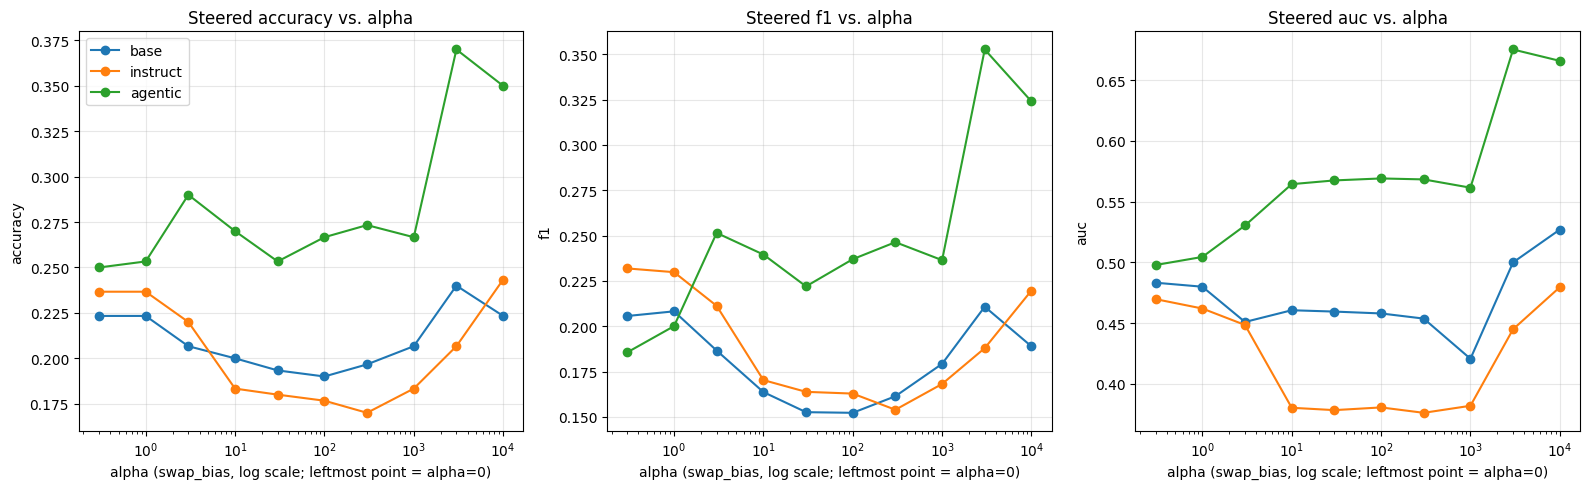

In [6]:
rows = []
for model_tag, by_alpha in results.items():
    for alpha, m in by_alpha.items():
        rows.append({"model": model_tag, "alpha": alpha, **m})
df = pd.DataFrame(rows)
pd.set_option("display.width", 140)
print(df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["accuracy", "f1", "auc"]):
    for model_tag in MODELS:
        sub = df[df["model"] == model_tag].sort_values("alpha")
        # alpha=0 can't go on a log axis; offset it slightly for display
        x = sub["alpha"].replace(0, 0.3)
        ax.plot(x, sub[metric], marker="o", label=model_tag)
    ax.set_xscale("log")
    ax.set_xlabel("alpha (swap_bias, log scale; leftmost point = alpha=0)")
    ax.set_ylabel(metric)
    ax.set_title(f"Steered {metric} vs. alpha")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.savefig("figures/alpha_ablation_qwen2vl.png", dpi=150)
plt.show()

## Result

(filled in after running)